# Importing Libraries

In [1]:
# Importing Libraries
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import scipy as sp
import numpy as np
import pandas as pd
import time
import datetime
import os
import sys
import pyvisa
import threading
import ipywidgets
import nidaqmx
import tkinter as tk
from tkinter import filedialog
from scipy import signal
from collections import deque
from nidaqmx.constants import AcquisitionType, TerminalConfiguration
from IPython.display import clear_output, display

print(f"All Libraries imported successfully at {datetime.datetime.now()}")

All Libraries imported successfully at 2026-08-19 09:20:10.214960


# Connecting NI DAQ USB-6341 via USB

In [2]:
# Function for connecting to the NI DAQ device via USB
def connect_daq():
    """Function to connect to the DAQ device and return the system object."""
    system = nidaqmx.system.System.local()
    for device in system.devices:
        print(f"Device Name:       {device.name}")
        print(f"Product Category:  {device.product_category}")
        print(f"Product Type:      {device.product_type}")
        ao_chans = [chan.name for chan in device.ao_physical_chans]
        ai_chans = [chan.name for chan in device.ai_physical_chans]
        di_lines = [line.name for line in device.di_lines]
        print(f"Analog Output Channels: {len(ao_chans)}")
        print(f"Analog Input Channels: {len(ai_chans)}")
        print(f"Digital Input Lines: {len(di_lines)}")

connect_daq()
print(f"\nNI DAQ connected successfully at {datetime.datetime.now()}")

Device Name:       Dev1
Product Category:  ProductCategory.X_SERIES_DAQ
Product Type:      USB-6341 (BNC)
Analog Output Channels: 2
Analog Input Channels: 16
Digital Input Lines: 24

NI DAQ connected successfully at 2026-08-19 09:20:10.519509


## Functions for saving, appending and loading files

At the starting of the measurement program use following lines to save the data in a csv file with headers

>`variable_names = ["Time_s", "Voltage_V"]`
>
>`filepath = save_data_file(variable_names, "filename.csv")`

in the measurement loop, use the following line (after creating the dataframe variable) to append data to the file

>`append_data_file(filepath, data_df)`


In [3]:
# Function for saving data file using a file saver dialog
def save_data_file(variable_names, filename):
    # Hide the main Tkinter window
    root = tk.Tk()
    root.withdraw()
    # Open file saver dialog
    file_path = filedialog.asksaveasfilename(
        title="Save Data File",
        initialfile=filename,
        defaultextension=".csv",
        filetypes=[("CSV files", "*.csv"),("Text files", "*.txt"),("DAT files", "*.dat"),("All files", "*.*"),])
    # If the user cancels the file selection, return None
    if not file_path:
        print("Save operation canceled.")
        return None
    # Create an empty DataFrame with variable names and write headers only
    try:
        header_df = pd.DataFrame(columns=variable_names)
        header_df.to_csv(file_path, index=False, header=True, sep=",")
        return file_path
    except Exception as e:
        print(f"Error initializing file: {e}")
        return None

# Function for appending data to the CSV file
def append_data_file(file_path, data_df):
    try:
        data_df.to_csv(file_path, mode="a", index=False, header=False, sep=",")
    except Exception as e:
        print(f"Error appending data: {e}")

# Function for loading data file using a file picker dialog
def load_data_file():
    # Hide the main Tkinter window
    root = tk.Tk()
    root.withdraw()
    # Open file picker dialog
    file_path = filedialog.askopenfilename(title="Load Data File",filetypes=[("Data Files", "*.csv *.txt *.dat"),("All files", "*.*")])
    # If the user cancels the file selection, return None
    if not file_path:
        print("Selection canceled.")
        return None
    # Load file as pandas DataFrame, automatically detecting the separator
    try:
        df = pd.read_csv(file_path, sep=None, engine="python")
        return df
    except Exception as e:
        print(f"Error loading file: {e}")
        return None

'''
# the starting of the measurement program use following lines to save the data in a csv file with headers

variable_names = ["Time_s", "Voltage_V"]
filepath = save_data_file(variable_names, "filename.csv")

# in the measurement loop, use the following line (after creating the dataframe variable) to append data to the file

append_data_file(filepath, data_df)
'''
print(f"File save/load functions initialized successfully at {datetime.datetime.now()}")

File save/load functions initialized successfully at 2026-08-19 09:20:10.529758


# Program for recording time trace from NI DAQ device with single ai_channel

In [ ]:
# Program for recording time trace from NI DAQ device with single ai_channel

set_voltage = 0  # Voltage to set on ao channel
total_samples = 2**24  # number of samples
sampling_rate = 100000.0  # samples per second
record_duration = total_samples / sampling_rate
time_data = np.arange(0, record_duration, 1/sampling_rate) # Time vector

ai_range = 0.2  # Voltage range for AI channel: 10, 5 , 1, 0.2
ai_channel = "Dev1/ai0"  # AI channel name

print(f"Data acquisition started at {datetime.datetime.now()}")
with nidaqmx.Task() as ai_task:
    ai_task.ai_channels.add_ai_voltage_chan(ai_channel,terminal_config=TerminalConfiguration.DIFF, min_val=-ai_range, max_val=ai_range)
    ai_task.timing.cfg_samp_clk_timing(sampling_rate, sample_mode=AcquisitionType.FINITE, samps_per_chan=total_samples)
    ai_task.timing.ai_conv_rate = 500000
    # Start the task and read the data
    ai_task.start()
    input_data = ai_task.read(number_of_samples_per_channel=total_samples,timeout=record_duration+10)
    ai_task.wait_until_done()

print(f"Data acquisition completed successfully at {datetime.datetime.now()}")

# Program for recording time trace from NI DAQ device simulataneously with 2 ai_channels

In [20]:
# Program for recording time trace from NI DAQ device simulataneously with 2 ai_channels

set_voltage = 0  # Voltage to set on ao channel
total_samples = 2**24  # number of samples
sampling_rate = 200000.0  # samples per second
record_duration = total_samples / sampling_rate
time_data = np.arange(0, record_duration, 1/sampling_rate) # Time vector

ai_range_1 = 0.2  # Voltage range for AI channel: 10, 5 , 1, 0.2
ai_channel_1 = "Dev1/ai0"  # AI channel name
ai_range_2 = 0.2  # Voltage range for AI channel: 10, 5 , 1, 0.2
ai_channel_2 = "Dev1/ai1"  # AI channel name

print(f"Data acquisition started at {datetime.datetime.now()}")
with nidaqmx.Task() as ai_task:
    ai_task.ai_channels.add_ai_voltage_chan(ai_channel_1,terminal_config=TerminalConfiguration.DIFF, min_val=-ai_range_1, max_val=ai_range_1)
    ai_task.ai_channels.add_ai_voltage_chan(ai_channel_2,terminal_config=TerminalConfiguration.DIFF, min_val=-ai_range_2, max_val=ai_range_2)
    ai_task.timing.cfg_samp_clk_timing(sampling_rate, sample_mode=AcquisitionType.FINITE, samps_per_chan=total_samples)
    ai_task.timing.ai_conv_rate = 500000
    # Start the task and read the data
    ai_task.start()
    input_data = ai_task.read(number_of_samples_per_channel=total_samples,timeout=record_duration+10)
    ai_task.wait_until_done()

input_data_1 = np.array(input_data[0])  # Data from first AI channel
input_data_2 = np.array(input_data[1])  # Data from second AI channel

print(f"Data acquisition completed successfully at {datetime.datetime.now()}")

Data acquisition started at 2026-08-19 09:32:28.578306
Data acquisition completed successfully at 2026-08-19 09:33:54.154942


In [ ]:
plt.figure(figsize=(20, 5))
plt.plot(time_data, np.array(input_data)*1e6, label='Input Read (Measured)')
plt.title(f"NI USB-6341: Time Trace at {set_voltage} V ({sampling_rate} samples/s)")
plt.xlabel("Time (s)")
plt.ylabel("Voltage ($\mu$V)")
plt.legend()
plt.grid(True)
plt.show()

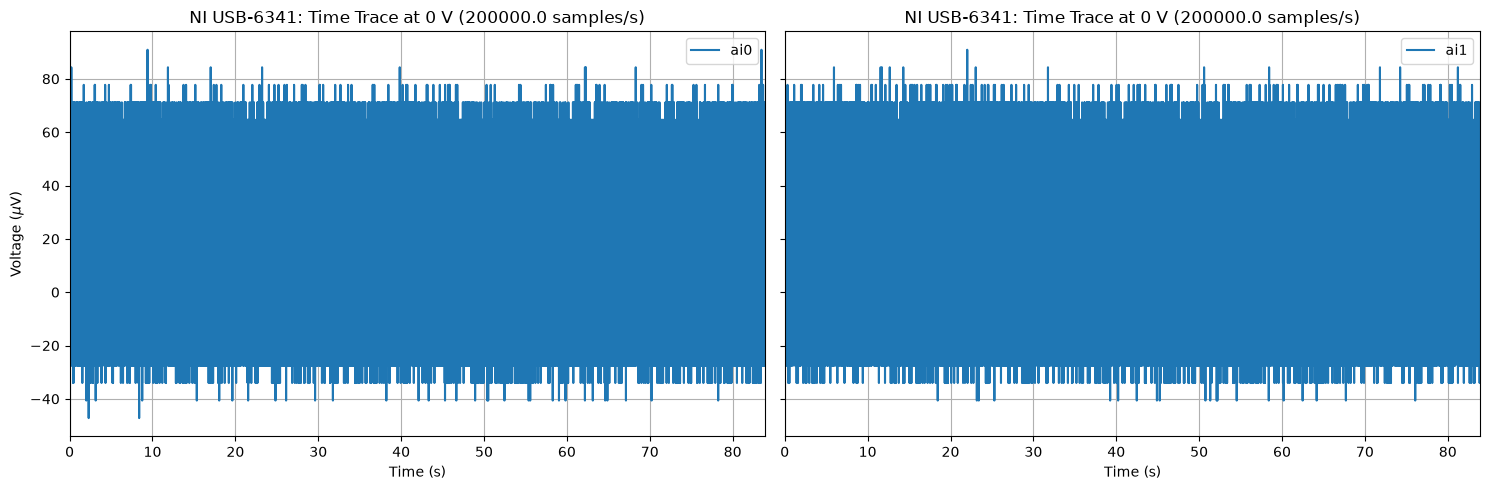

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), sharey=True, layout='tight')
# --- Left Subplot ---
ax1.plot(time_data, input_data_1 * 1e6, label="ai0")
ax1.set_title(f"NI USB-6341: Time Trace at {set_voltage} V ({sampling_rate} samples/s)")
ax1.set_xlabel("Time (s)")
ax1.set_xlim(0, record_duration)
ax1.set_ylabel("Voltage ($\mu$V)")
ax1.legend()
ax1.grid(True)
# --- Right Subplot ---
ax2.plot(time_data, input_data_2 * 1e6, label="ai1")
ax2.set_title(f"NI USB-6341: Time Trace at {set_voltage} V ({sampling_rate} samples/s)")
ax2.set_xlabel("Time (s)")
ax2.set_xlim(0, record_duration)
ax2.legend()
ax2.grid(True)
plt.show()

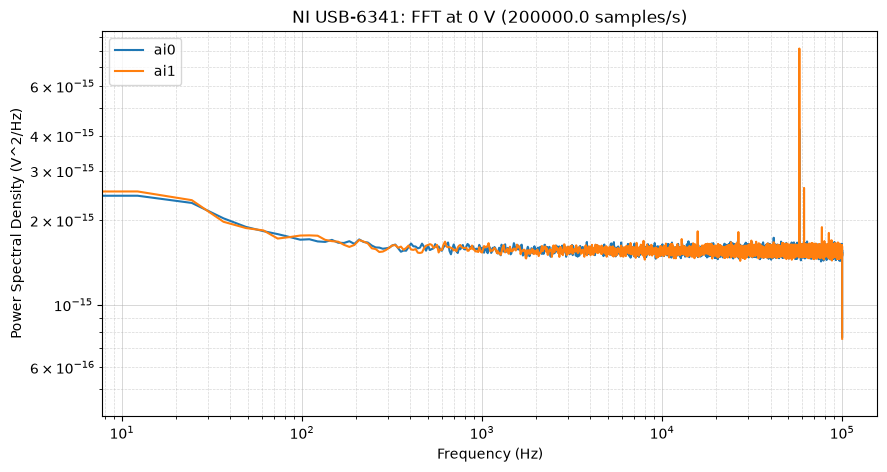

In [24]:
f_welch_0,psd_welch_0 = signal.welch(input_data_1, fs=sampling_rate, nperseg=2**14,window='hann', noverlap=None, detrend='constant', return_onesided=True, scaling='density')
f_welch_1,psd_welch_1 = signal.welch(input_data_2, fs=sampling_rate, nperseg=2**14,window='hann', noverlap=None, detrend='constant', return_onesided=True, scaling='density')
f_0,psd_0 = signal.periodogram(input_data_1, fs=sampling_rate, window='hann', detrend='constant', return_onesided=True, scaling='density')
f_1,psd_1 = signal.periodogram(input_data_2, fs=sampling_rate, window='hann', detrend='constant', return_onesided=True, scaling='density')
# Plot FFT
plt.figure(figsize=(10, 5))
plt.loglog(f_welch_0, psd_welch_0, label='ai0')
plt.loglog(f_welch_1, psd_welch_1, label='ai1')
plt.title(f"NI USB-6341: FFT at {set_voltage} V ({sampling_rate} samples/s)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (V^2/Hz)")
plt.legend()
plt.grid(True, which='major', ls='-', lw=0.5, alpha=0.7)
plt.grid(True, which='minor', ls='--', lw=0.5, alpha=0.5)
plt.show()

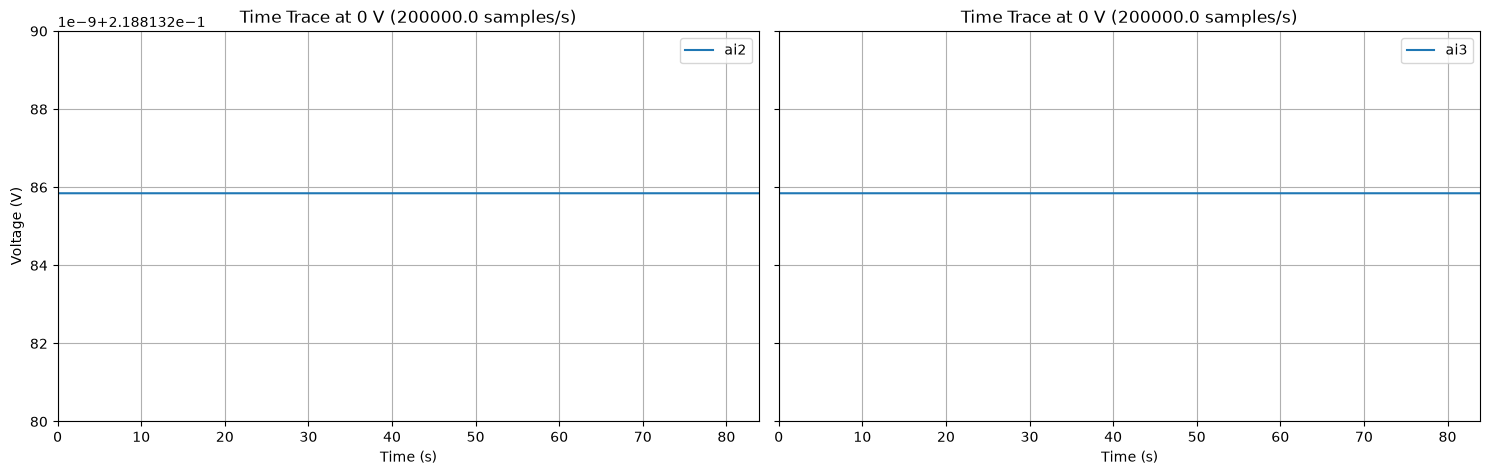

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), sharey=True, layout='tight')
# --- Left Subplot ---
ax1.plot(time_data, input_data_1, label="ai2")
ax1.set_title(f"Time Trace at {set_voltage} V ({sampling_rate} samples/s)")
ax1.set_xlabel("Time (s)")
ax1.set_xlim(0, record_duration)
ax1.set_ylim(0.21881328, 0.21881329)
ax1.set_ylabel("Voltage (V)")
ax1.legend()
ax1.grid(True)
# --- Right Subplot ---
ax2.plot(time_data, input_data_2, label="ai3")
ax2.set_title(f"Time Trace at {set_voltage} V ({sampling_rate} samples/s)")
ax2.set_xlabel("Time (s)")
ax2.set_xlim(0, record_duration)
ax2.legend()
ax2.grid(True)
plt.show()

c:\Users\kuldeek2\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


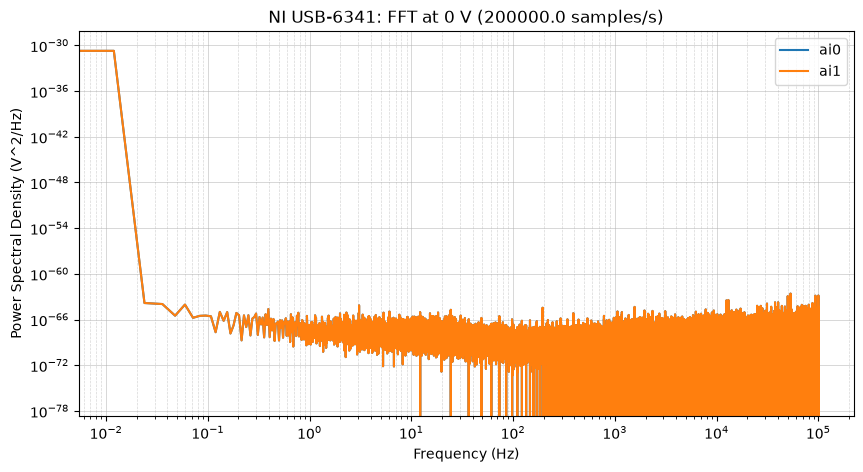

In [19]:
f_welch_0,psd_welch_0 = signal.welch(input_data_1, fs=sampling_rate, nperseg=2**24,window='hann', noverlap=None, detrend='constant', return_onesided=True, scaling='density')
f_welch_1,psd_welch_1 = signal.welch(input_data_2, fs=sampling_rate, nperseg=2**24,window='hann', noverlap=None, detrend='constant', return_onesided=True, scaling='density')
f_0,psd_0 = signal.periodogram(input_data_1, fs=sampling_rate, window='hann', detrend='constant', return_onesided=True, scaling='density')
f_1,psd_1 = signal.periodogram(input_data_2, fs=sampling_rate, window='hann', detrend='constant', return_onesided=True, scaling='density')
# Plot FFT
plt.figure(figsize=(10, 5))
plt.loglog(f_welch_0, psd_welch_0, label='ai0')
plt.loglog(f_welch_1, psd_welch_1, label='ai1')
plt.title(f"NI USB-6341: FFT at {set_voltage} V ({sampling_rate} samples/s)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (V^2/Hz)")
plt.legend()
plt.grid(True, which='major', ls='-', lw=0.5, alpha=0.7)
plt.grid(True, which='minor', ls='--', lw=0.5, alpha=0.5)
plt.show()

In [ ]:
variable_names = ["Time_s", "Voltage_V"]
filepath = save_data_file(variable_names, f"Time_trace_{total_samples}_samples_{sampling_rate}_Hz_ai2_v1.csv")
df = pd.DataFrame({"Time_s": time_data, "Voltage_V": input_data_1})
append_data_file(filepath, df)

In [ ]:
variable_names = ["Frequency_Hz", "PSD_V2_per_Hz"]
filepath = save_data_file(variable_names, f"PSD_welch_{total_samples}_samples_{sampling_rate}_Hz_ai2_v1.csv")
df = pd.DataFrame({"Frequency_Hz": f_welch_0, "PSD_V2_per_Hz": psd_welch_0})
append_data_file(filepath, df)